In [2]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from datetime import datetime, timedelta
import datajoint as dj

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-04-08 19:54:02,853][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-04-08 19:54:03,241][INFO]: DataJoint 0.14.8 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [5]:
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe, ephys_sorter

Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


# Select Experiment

In [6]:
organoid_id = "O09"
drug_name = "Control"

exp_key = {
    "organoid_id": organoid_id,
    "experiment_start_time": (culture.Experiment & f"organoid_id = '{organoid_id}'" & f"drug_name = '{drug_name}'").fetch1("experiment_start_time"),
}

culture.Experiment & exp_key

organoid_id e.g. O17,experiment_start_time,experiment_end_time,user,lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,organoid_culture_date,organoid_culture_plate,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
O09,2023-05-03 17:33:00,2023-05-18 12:15:00,None,None,None,None,None,None,None,None,None,None,Control,nan,ephys


# Select Analysis Boundaries

In [7]:
boundary_start = (culture.Experiment & exp_key).fetch1("experiment_start_time") + timedelta(hours=1)
boundary_end = boundary_start + timedelta(days=2)

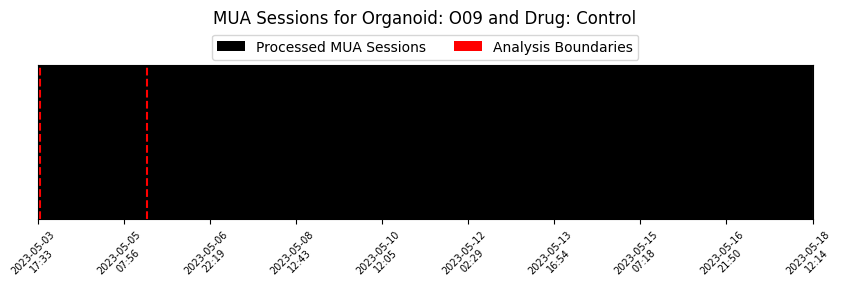

In [8]:
def downsample_to_length(x, n_new):

    """Downsample 1D array x to length n_new using linear interpolation."""
    new_idx = np.linspace(0, x.size - 1, n_new).astype(int)
    return x[new_idx]

# determine the experiment boundaries (based on exp_key)
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")

# find the available files within the experiment boundaries
file_times = (ephys.EphysRawFile & exp_key & f"file_time >= '{experiment_start_time}' AND file_time < '{experiment_end_time}'").fetch("file_time")

# find the processed MUA sessions within the experiment boundaries
processed_file_times = (mua.MUAEphysSession & exp_key & f"start_time >= '{experiment_start_time}' AND start_time < '{experiment_end_time}'").fetch("start_time")

# create a visualization of the data already processed for the given exp_key
fig = plt.figure(figsize=(10, 2))
ax = fig.gca()

processed_bool = np.isin(file_times, processed_file_times)
ax.imshow(processed_bool[np.newaxis, :], aspect="auto", cmap="binary")

# plot manually selected boundaries as red vertical lines
start_x = np.searchsorted(file_times, boundary_start)
end_x = np.searchsorted(file_times, boundary_end)
ax.axvline(start_x, color="red", linestyle="--", label="Analysis Boundaries")
ax.axvline(end_x, color="red", linestyle="--")

xticks = [d.strftime('%Y-%m-%d\n%H:%M') for d in downsample_to_length(file_times, 10)]
ax.set_xticks(np.linspace(0, len(file_times) - 1, 10))
ax.set_xticklabels(xticks, rotation=45, fontsize=7)
ax.set_yticks([])

ax.set_title(f"MUA Sessions for Organoid: {organoid_id} and Drug: {drug_name}", pad=30)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='black', label='Processed MUA Sessions'), Patch(facecolor='red', label='Analysis Boundaries')]
ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 2.1),
    borderaxespad=10,
    ncol=2
)

plt.show()

In [9]:
# Check if all files within the selected boundaries have been processed
analysis_files = file_times[(file_times >= boundary_start) & (file_times <= boundary_end)]

if all(np.isin(analysis_files, processed_file_times)):
    print("All files within the selected boundaries have been processed.")
else:
    print(f"{len(analysis_files) - np.sum(np.isin(analysis_files, processed_file_times))} Files within the selected boundaries are yet to be processed.")

All files within the selected boundaries have been processed.


# Select Parameters for Frame Analysis

In [9]:
frame.TimeFrameParamset()

frame_param_idx Unique identifier for the frame parameter set,num_frames Number of frames to extract,min_per_frame Length of each frame in minutes
1,12,5
2,4,15
3,8,15
4,24,15
5,60,5
6,8,5
7,2,5


Optional: Create Parameterset

In [ ]:
insert_key = {
    "frame_param_idx": 7,
    "num_frames": 2,
    "min_per_frame": 5
}

frame.TimeFrameParamset.insert1(insert_key, skip_duplicates=True)

## Insert New Frame Analysis Session

In [11]:
key = {
    **exp_key,
    "start_boundary": boundary_start,
    "end_boundary": boundary_end,
    "frame_param_idx": 6
}

In [10]:
# frame.FrameSession.insert1(key, skip_duplicates=True)
frame.FrameSession & key

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6


In [11]:
frame.FrameAnalysis.populate(key)
frame.FrameAnalysis.ActiveTimeFrames & key

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset,frame_start Start of active time frame,frame_end End of active time frame,frame_firing_rate Firing rates for each frame
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 19:43:49,2023-05-03 19:48:48,0.01
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 20:32:49,2023-05-03 20:37:48,0.0533334
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 22:11:49,2023-05-03 22:16:48,0.01
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-03 23:00:49,2023-05-03 23:05:48,0.0233334
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-04 12:48:52,2023-05-04 12:53:51,0.01
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-04 15:17:52,2023-05-04 15:22:51,0.00666668
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-04 17:45:52,2023-05-04 17:50:51,0.0133334
O10,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2023-05-05 17:04:52,2023-05-05 17:09:51,0.0466668


# Inspect Extracted Active Time Frames

In [12]:
# Fetch MUA Firing Rates Between Boundaries
start_times, spike_rates = (mua.MUASpikes.Channel & key & f"start_time BETWEEN '{boundary_start}' AND '{boundary_end}'").fetch("start_time", "spike_rate")  

# Create population firing vector (sum spike rates across channels)
time_vector = np.arange(min(start_times), max(start_times), timedelta(minutes=1)).astype('datetime64[m]')

start_times_dt64 = start_times.astype('datetime64[m]')
population_firing_vector = np.zeros_like(time_vector, dtype=float)
for t in time_vector:

    time_bool = start_times_dt64 == t
    population_firing_vector[np.where(time_vector == t)[0][0]] = np.sum(spike_rates[time_bool])

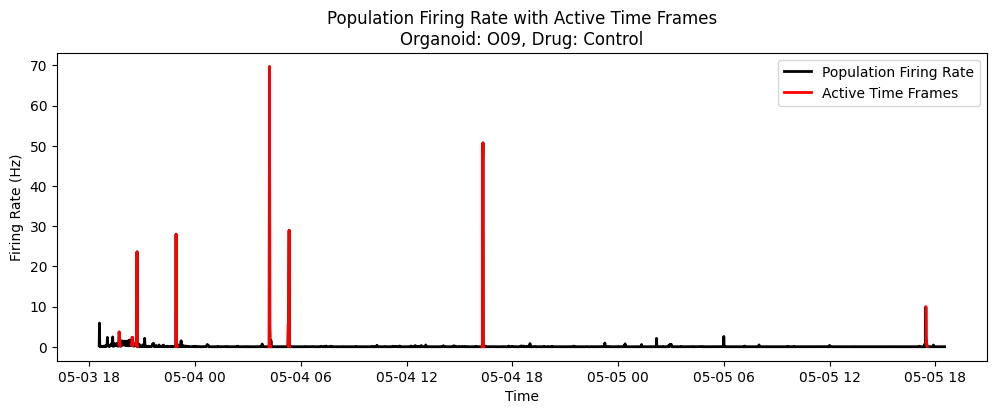

In [ ]:
# Extract Active Time Frames (sorted by firing rate)
frame_start, frame_end = (frame.FrameAnalysis.ActiveTimeFrames & key).fetch("frame_start", "frame_end", order_by="frame_start")

# Plot Population Firing Rate with Active Time Frames Highlighted in Red
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_vector, population_firing_vector, label="Population Firing Rate", color="black", linewidth=2)
for start, end in zip(frame_start, frame_end):
    active_time_mask = (np.datetime64(start, "m") <= time_vector) & (time_vector <= np.datetime64(end, "m"))
    ax.plot(time_vector[active_time_mask], population_firing_vector[active_time_mask], color="red", linewidth=2)
ax.plot([], [], color="red", label="Active Time Frames", linewidth=2)  # Dummy line for legend
ax.set_xlabel("Time")
ax.set_ylabel("Firing Rate (Hz)")
ax.set_title(f"Population Firing Rate with Active Time Frames\nOrganoid: {organoid_id}, Drug: {drug_name}")
ax.legend()
plt.show()

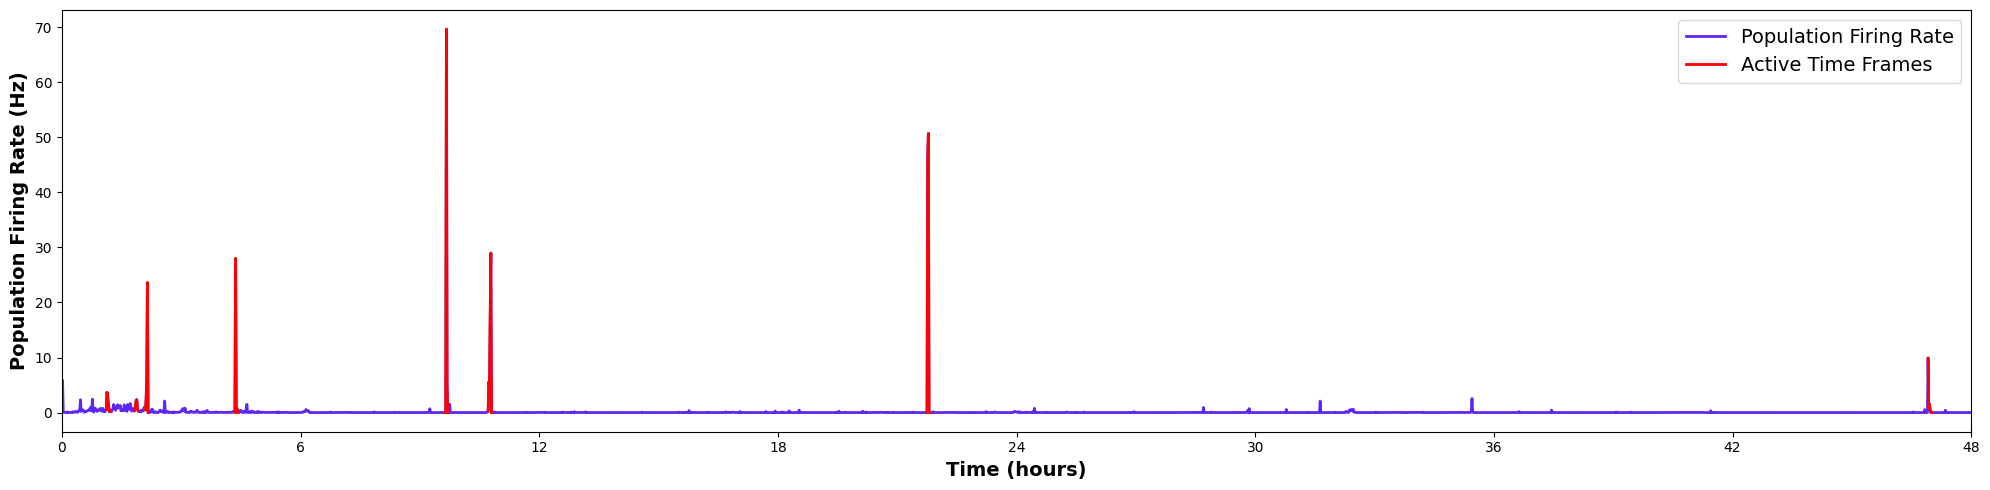

In [21]:
# Extract Active Time Frames (sorted by firing rate)
frame_start, frame_end = (frame.FrameAnalysis.ActiveTimeFrames & key).fetch("frame_start", "frame_end", order_by="frame_start")

x = np.arange(len(time_vector))
# Plot Population Firing Rate with Active Time Frames Highlighted in Red
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(x, population_firing_vector, label="Population Firing Rate", color="#5E27F5", linewidth=2)
for start, end in zip(frame_start, frame_end):
    active_time_mask = (np.datetime64(start, "m") <= time_vector) & (time_vector <= np.datetime64(end, "m"))
    ax.plot(x   [active_time_mask], population_firing_vector[active_time_mask], color="red", linewidth=2)
ax.plot([], [], color="red", label="Active Time Frames", linewidth=2)  # Dummy line for legend

xticks = np.arange(0, len(time_vector)+1, 60*6)  # every 6 hours
xticks_labels = np.arange(len(xticks)) * 6  # Assuming time_vector is in minutes, this will label every 6 hours
ax.set_xticks(xticks, labels=xticks_labels)
ax.set_xlim(0, len(time_vector))

ax.set_xlabel("Time (hours)", fontsize=14, fontweight="bold")
ax.set_ylabel("Population Firing Rate (Hz)", fontsize=14, fontweight="bold")
ax.legend(fontsize=14)
fig.tight_layout()
plt.show()

## Insert Analysis Tables based on Active Time Frames

In [16]:
# Parameters for complete session analysis
insertion_number = 2 # for frame analysis
session_type = 'both'

probe_name = 'Q983'
port_id = 'A'
used_electrodes = []

burst_param_idx = 1

sorter_param_idx = 3045

spec_param_idx = 0

fooof_param_idx = 2
fbosc_param_idx = 0
start_freq = 2
end_freq = 300
analysis_electrodes = list(range((culture.OrganoidImplantationImage & f"organoid_id = '{organoid_id}'").fetch1("num_electrodes_inside")))  

In [17]:
for i, (start_time, end_time) in enumerate(zip(frame_start, frame_end)):
    print(start_time, end_time)

2023-05-19 13:06:06 2023-05-19 13:11:05
2023-05-19 13:22:06 2023-05-19 13:27:05


In [18]:
frame.FrameAnalysis & "frame_param_idx IN (6, 7)"

organoid_id e.g. O17,experiment_start_time,start_boundary Start datetime for analysis,end_boundary End datetime for analysis,frame_param_idx Reference to TimeFrameParamset,num_processed_sessions Number of sessions with available data within the analysis boundaries,num_available_files Number of available ephys files within the analysis boundaries
O09,2023-05-03 17:33:00,2023-05-03 18:33:00,2023-05-05 18:33:00,6,2880,2880
O09,2023-05-03 17:33:00,2023-05-16 11:15:00,2023-05-18 11:15:00,6,2880,2880
O09,2023-05-18 12:25:00,2023-05-18 12:40:00,2023-05-18 16:40:00,7,240,240
O09,2023-05-18 18:15:00,2023-05-19 05:15:00,2023-05-19 09:15:00,7,240,240
O09,2023-05-19 09:30:00,2023-05-19 09:45:00,2023-05-19 13:45:00,7,240,240
O09,2023-05-19 15:45:00,2023-05-19 16:00:00,2023-05-19 20:00:00,7,240,240


In [19]:
def insert_ephys_sessions(frame_key):

    print(f"Inserting Ephys Sessions for {frame_key}")

    session_keys = (frame.FrameAnalysis.ActiveTimeFrames & frame_key).fetch("KEY")
    
    for session_key in session_keys:
        key = {
            "organoid_id": session_key["organoid_id"],
            "experiment_start_time": session_key["experiment_start_time"],
            "start_time": session_key["frame_start"],
            "end_time": session_key["frame_end"],
            "insertion_number": insertion_number,
        }

        # Ephys Session
        ephys_key = {
            **key,
            "session_type": session_type
        }
        probe_key = {
            **key,
            "probe": probe_name,
            "port_id": port_id,
            "used_electrodes": used_electrodes
        }

        ephys.EphysSession.insert1(ephys_key, skip_duplicates=True)
        ephys.EphysSessionProbe.insert1(probe_key, skip_duplicates=True)
        ephys.EphysSessionInfo.populate(key)

def insert_analysis(frame_key):

    session_keys = (frame.FrameAnalysis.ActiveTimeFrames & frame_key).fetch("KEY")
    
    for session_key in session_keys:
        key = {
            "organoid_id": session_key["organoid_id"],
            "experiment_start_time": session_key["experiment_start_time"],
            "start_time": session_key["frame_start"],
            "end_time": session_key["frame_end"],
            "insertion_number": insertion_number,
        }    

        # MUA Population Bursts
        print(f"Inserting MUA Population Burst Analysis for {key}")

        mua_key = {
            **key,
            "burst_param_idx": burst_param_idx
        }
        mua.BurstSession.insert1(mua_key, skip_duplicates=True)
        mua.PopulationBursts.populate(key)

        # Spectral Analysis
        print(f"Inserting Spectral Analysis for {key}")

        ephys.LFP.populate(key)

        trace_keys = [
            {**trace_key, "param_idx": spec_param_idx} 
            for trace_key in (ephys.LFP.Trace & key).fetch("KEY")
            ]

        analysis.LFPSpectrogram.populate(trace_keys)
        analysis.STTFA.populate(trace_keys)

        # Coherence Analysis
        print(f"Inserting Coherence Analysis for {key}")

        analysis.Coherence.populate(key)        

        # FOOOF and fBOSC analysis
        print(f"Inserting FOOOF and fBOSC Analysis for {key}")

        fooof_key = {
            **key,
            "fooof_param_idx": fooof_param_idx,
            "fbosc_param_idx": fbosc_param_idx,
            "start_freq": start_freq,
            "end_freq": end_freq,
            "analysis_electrodes": analysis_electrodes
        }
        
        analysis.FOOOFandFBOSCSession.insert1(fooof_key, skip_duplicates=True)
        analysis.FOOOFAnalysis.populate(fooof_key)

In [117]:
frame_keys = (frame.FrameAnalysis & "frame_param_idx IN (6, 7)").fetch("KEY")

for frame_key in frame_keys:
    insert_ephys_sessions(frame_key)

for frame_key in frame_keys:
    insert_analysis(frame_key)

[2026-03-13 17:38:08,195][WARNING]: Reconnecting to MySQL server.


Inserting Ephys Sessions for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'start_boundary': datetime.datetime(2023, 5, 3, 18, 33), 'end_boundary': datetime.datetime(2023, 5, 5, 18, 33), 'frame_param_idx': 6}


[2026-03-13 17:38:09,478][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 3, 19, 40, 49), 'end_time': datetime.datetime(2023, 5, 3, 19, 45, 48)}>
[2026-03-13 17:38:10,213][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 3, 20, 23, 49), 'end_time': datetime.datetime(2023, 5, 3, 20, 28, 48)}>
[2026-03-13 17:38:10,961][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 3, 20, 38, 49), 'end_time': datetime.datetime(2023, 5, 3, 20, 43, 48)}>
[2026-03-13 17:38:11,694][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_ti

Inserting Ephys Sessions for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'start_boundary': datetime.datetime(2023, 5, 16, 11, 15), 'end_boundary': datetime.datetime(2023, 5, 18, 11, 15), 'frame_param_idx': 6}


[2026-03-13 17:38:15,434][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 16, 14, 21, 5), 'end_time': datetime.datetime(2023, 5, 16, 14, 26, 4)}>
[2026-03-13 17:38:16,193][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 16, 17, 12, 5), 'end_time': datetime.datetime(2023, 5, 16, 17, 17, 4)}>
[2026-03-13 17:38:16,941][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 16, 17, 23, 5), 'end_time': datetime.datetime(2023, 5, 16, 17, 28, 4)}>
[2026-03-13 17:38:17,700][INFO]: Populating ephys.EphysSessionInfo for <{'organoid_id': 'O09', 'experiment_start_ti

...

[2026-03-13 20:44:49,627][INFO]: Populating ephys.LFP for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5)}>


Inserting Spectral Analysis for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5), 'insertion_number': 2}


[2026-03-13 20:45:14,165][INFO]: Populating ephys.LFP for <{'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'insertion_number': 2, 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5)}>


Inserting Coherence Analysis for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5), 'insertion_number': 2}
Inserting FOOOF and fBOSC Analysis for {'organoid_id': 'O09', 'experiment_start_time': datetime.datetime(2023, 5, 19, 15, 45), 'start_time': datetime.datetime(2023, 5, 19, 19, 33, 6), 'end_time': datetime.datetime(2023, 5, 19, 19, 38, 5), 'insertion_number': 2}


c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\plotly\matplotlylib\renderer.py:609: UserWarning:

I found a path object that I don't think is part of a bar chart. Ignoring.

c:\users\organoid pc\documents\github\fooof\specparam\modes\funcs.py:115: RuntimeWarning:

invalid value encountered in log10



In [16]:
# insert data for each session
def insert_data(key):
    """
    key = FrameAnalysis key
    """
    for i, (start_time, end_time) in enumerate(zip(frame_start, frame_end)):

        print(f"Session {i} ({start_time} to {end_time}):")
        session_start_time = datetime.now()

        key = {
            "organoid_id": organoid_id,
            "experiment_start_time": experiment_start_time,
            "insertion_number": insertion_number,
            "start_time": start_time,
            "end_time": end_time,
        }

        # Ephys Session
        ephys_key = {
            **key,
            "session_type": session_type
        }
        probe_key = {
            **key,
            "probe": probe_name,
            "port_id": port_id,
            "used_electrodes": used_electrodes
        }

        ephys.EphysSession.insert1(ephys_key, skip_duplicates=True)
        ephys.EphysSessionProbe.insert1(probe_key, skip_duplicates=True)
        ephys.EphysSessionInfo.populate(key)

        # MUA Population Bursts
        mua_start_time = datetime.now()
        print(f"  Ephys session inserted. Time taken: {mua_start_time - session_start_time}")

        mua_key = {
            **key,
            "burst_param_idx": burst_param_idx
        }
        mua.BurstSession.insert1(mua_key, skip_duplicates=True)
        mua.PopulationBursts.populate(key)

        # Spike Sorting
        spike_sorting_start_time = datetime.now()
        print(f"  MUA population bursts inserted. Time taken: {spike_sorting_start_time - mua_start_time}")

        sua_key = {
            **key,
            "paramset_idx": sorter_param_idx
        }
        # ephys.ClusteringTask.insert1(sua_key, skip_duplicates=True)
        # ephys_sorter.PreProcessing.populate(sua_key)
        # ephys_sorter.SIClustering.populate(sua_key)
        # ephys_sorter.PostProcessing.populate(sua_key)
        # ephys.CuratedClustering.populate(sua_key)

        sua_sorting_start_time = datetime.now()
        print(f"  Spike sorting completed. Time taken: {sua_sorting_start_time - spike_sorting_start_time}")

        # ephys.WaveformSet.populate(sua_key)
        # ephys.QualityMetrics.populate(sua_key)

        sttc_start_time = datetime.now()
        print(f"  Waveforms and quality metrics populated. Time taken: {sttc_start_time - sua_sorting_start_time}")

        # ephys.STTC.populate(sua_key)

        # Spectral Analysis
        trace_start_time = datetime.now()
        print(f"  STTC populated. Time taken: {trace_start_time - sttc_start_time}")

        ephys.LFP.populate(key)

        trace_keys = [
            {**trace_key, "param_idx": spec_param_idx} 
            for trace_key in (ephys.LFP.Trace & key).fetch("KEY")
            ]
        
        spectral_start_time = datetime.now()
        print(f"  LFP traces populated. Time taken: {spectral_start_time - trace_start_time}")

        analysis.LFPSpectrogram.populate(trace_keys)
        analysis.STTFA.populate(trace_keys)

        # Coherence Analysis
        coherence_start_time = datetime.now()
        print(f"  Spectrogram and STTFA populated. Time taken: {coherence_start_time - spectral_start_time}")

        analysis.Coherence.populate(key)

        # FOOOF and fBOSC analysis
        fooof_start_time = datetime.now()
        print(f"  Coherence populated. Time taken: {fooof_start_time - coherence_start_time}")

        fooof_key = {
            **key,
            "fooof_param_idx": fooof_param_idx,
            "fbosc_param_idx": fbosc_param_idx,
            "start_freq": start_freq,
            "end_freq": end_freq,
            "analysis_electrodes": analysis_electrodes
        }
        analysis.FOOOFandFBOSCSession.insert1(fooof_key, skip_duplicates=True)
        analysis.FOOOFAnalysis.populate(fooof_key)

        session_end_time = datetime.now()
        print(f"  FOOOF and fBOSC analysis completed. Time taken: {session_end_time - fooof_start_time}")
        print(f"Total time taken for session {i}: {session_end_time - session_start_time}\n")

In [18]:
# Insert spike sorting sessions
frame_keys = (frame.FrameAnalysis.ActiveTimeFrames & "frame_param_idx = 6" & f"frame_start < '{datetime(2023, 5, 10)}'").fetch("KEY")

sua_keys = [
    {
        "organoid_id": frame_key["organoid_id"],
        "experiment_start_time": frame_key["experiment_start_time"],
        "start_time": frame_key["frame_start"],
        "end_time": frame_key["frame_end"],
        "insertion_number": insertion_number,
        "paramset_idx": 409
    }
    for frame_key in frame_keys
    ]

In [19]:
sua_key = sua_keys[0]
sua_key

{'organoid_id': 'O09',
 'experiment_start_time': datetime.datetime(2023, 5, 3, 17, 33),
 'start_time': datetime.datetime(2023, 5, 3, 19, 40, 49),
 'end_time': datetime.datetime(2023, 5, 3, 19, 45, 48),
 'insertion_number': 2,
 'paramset_idx': 409}

In [20]:
ephys.ClusteringTask.insert1(sua_key, skip_duplicates=True)
ephys.ClusteringTask & sua_key

organoid_id e.g. O17,experiment_start_time,insertion_number,start_time,end_time,paramset_idx,clustering_output_dir clustering output directory relative to the clustering root data directory
O09,2023-05-03 17:33:00,2,2023-05-03 19:40:49,2023-05-03 19:45:48,409,


In [21]:
ephys_sorter.PreProcessing.populate(sua_key)

[2026-03-26 19:11:09,390][INFO]: D:\processed_data\O09-12_raw\202305031940_202305031945\O09\kilosort4_409 created!


{'success_count': 1, 'error_list': []}

In [22]:
ephys_sorter.SIClustering.populate(sua_key)

[2026-03-26 19:11:11,658][INFO]: No existing results found, calling '_run_sorter'


installation_mode='auto' switching to installation_mode: 'github'
kilosort4 supports GPU, but no GPU is available.
Running the sorter without GPU
Starting container
Installing spikeinterface with github in container
Installing neo with pypi in container
Running kilosort4 sorter inside spikeinterface/kilosort4-base
Stopping container


{'success_count': 1, 'error_list': []}

In [23]:
ephys_sorter.PostProcessing.populate(sua_key)

[2026-03-26 19:14:22,091][INFO]: No existing results found, calling '_sorting_analyzer_compute'


estimate_sparsity (no parallelization):   0%|          | 0/300 [00:00<?, ?it/s]

compute_waveforms (workers: 10 processes spawn):   0%|          | 0/150 [00:00<?, ?it/s]

noise_level (workers: 10 processes spawn):   0%|          | 0/20 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/8 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/8 [00:00<?, ?it/s]

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\postprocessing\principal_component.py:558: UserWarning:

Projection attempted on unfitted PCA models. This could be due to a small number of waveforms for a particular unit.

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning:

unsafe cast from uint64 to int64. Precision may be lost.

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\metrics\template\template_metrics.py:296: UserWarning:

With less than 10 channels, multi-channel metrics might not be reliable.

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\metrics\template\metrics.py:936: OptimizeWarning:

Covariance of the parameters could not be estimated

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\metrics\template\metrics.py:936: OptimizeWarn

Compute : spike_amplitudes + spike_locations (workers: 10 processes spawn):   0%|          | 0/150 [00:00<?, ?…

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning:

Amplitude cutoff set to NaN for units [0, 1, 2, 3, 4, 5, 6, 7]: too few spikes (< 500).

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1323: UserWarning:

Drift metrics could not be computed for units [0, 1, 2, 3, 4, 5, 6, 7] because they have less than 2 bins given the specified 'interval_s' and 'min_num_bins' or not enough valid intervals.

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\spikeinterface\metrics\quality\pca_metrics.py:370: RuntimeWarning:

Degrees of freedom <= 0 for slice

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning:

divide by zero encountered in divide

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\numpy\lib\function_base.py:2748: RuntimeWarning:

i

{'success_count': 1, 'error_list': []}

In [24]:
ephys.CuratedClustering.populate(sua_key)

{'success_count': 1, 'error_list': []}

In [25]:
ephys.WaveformSet.populate(sua_key)

{'success_count': 1, 'error_list': []}

In [26]:
ephys.QualityMetrics.populate(sua_key)

{'success_count': 1, 'error_list': []}

In [50]:
files, file_times = (
    ephys.EphysRawFile
    & sua_key
    & f"file_time BETWEEN '{sua_key['start_time']}' AND '{sua_key['end_time']}'"
).fetch("file_path", "file_time", order_by="file_time")
files

array(['O09-12_raw/processed_O9-12_230503_194049.rhd',
       'O09-12_raw/processed_O9-12_230503_194149.rhd',
       'O09-12_raw/processed_O9-12_230503_194249.rhd',
       'O09-12_raw/processed_O9-12_230503_194349.rhd',
       'O09-12_raw/processed_O9-12_230503_194449.rhd'], dtype=object)

In [67]:
import numpy as np
from pathlib import Path
import spikeinterface as si

# Full path to si_recording.pkl
path = Path(r"D:\\processed_data\\O09-12_raw\\202305031940_202305031945\\O09\\kilosort4_4037\\kilosort4\\recording\\si_recording.pkl")

# Load recording from pkl
# If the pkl was saved with relative paths, base_folder helps resolve them.
try:
    rec = si.load(path)
except Exception:
    rec = si.load(path, base_folder=path.parents[3])

fs = rec.get_sampling_frequency()
nch = rec.get_num_channels()

print("sampling_frequency:", fs)
print("num_channels:", nch)
print("dtype:", rec.get_dtype())
print("has_scaleable_traces:", rec.has_scaleable_traces())

gains = rec.get_channel_gains()
offsets = rec.get_channel_offsets()
print("gain min/max:", np.nanmin(gains), np.nanmax(gains))
print("offset min/max:", np.nanmin(offsets), np.nanmax(offsets))

# Grab ~1 second from first 9 channels (or fewer)
num_ch = min(8, nch)
start_frame = 60 * int(fs)  * 1
end_frame = 60 * int(fs) * 2
tr_raw = rec.get_traces(
    start_frame=start_frame,
    end_frame=end_frame,
    channel_ids=[rec.channel_ids[8]],
    return_in_uV=False,
)
tr_scaled = rec.get_traces(
    start_frame=start_frame,
    end_frame=end_frame,
    channel_ids=[rec.channel_ids[8]],
    return_in_uV=True,
)

def summarize(x, name):
    p1, p50, p99 = np.percentile(x, [1, 50, 99])
    print(f"{name} p1/p50/p99: {p1:.3f}, {p50:.3f}, {p99:.3f}")
    print(f"{name} std: {np.std(x):.3f}")
    print(f"{name} max abs: {np.max(np.abs(x)):.3f}")

summarize(tr_raw, "raw")
summarize(tr_scaled, "scaled")

# Ratio between scaled and raw spread (rough effective gain)
raw_std = np.std(tr_raw)
scaled_std = np.std(tr_scaled)
print("scaled/raw std ratio:", scaled_std / raw_std if raw_std > 0 else np.nan)

sampling_frequency: 20000.0
num_channels: 32
dtype: int16
has_scaleable_traces: True
gain min/max: 0.195 0.195
offset min/max: 0 0
raw p1/p50/p99: -105.000, 0.000, 104.000
raw std: 57.466
raw max abs: 2137.000
scaled p1/p50/p99: -20.475, 0.000, 20.280
scaled std: 11.206
scaled max abs: 416.715
scaled/raw std ratio: 0.1949999966403368


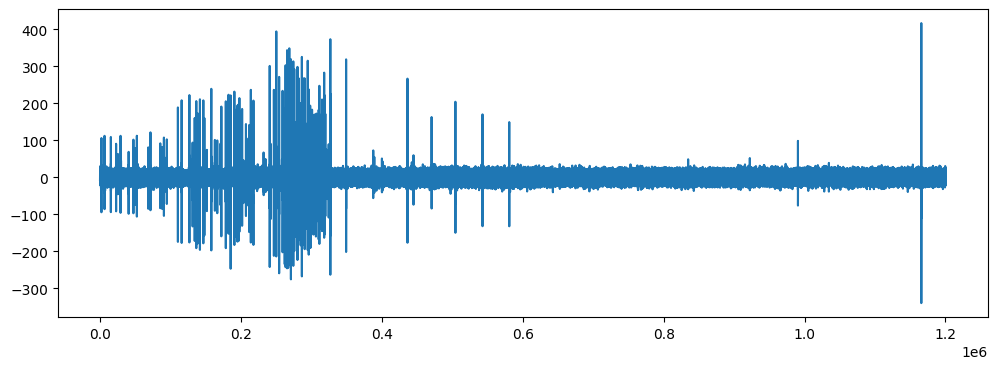

In [68]:
# adjust figsize
plt.figure(figsize=(12, 4))
plt.plot(tr_scaled, label="scaled")


In [65]:
probe.ElectrodeConfig.Electrode()

electrode_config_hash,probe_type e.g. A1x32-6mm-100-177-H32_21mm,"electrode electrode index, starts at 0","channel_idx channel name fetched from raw data (e.g., A-001)"
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,0,16
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,1,15
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,2,17
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,3,14
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,4,18
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,5,13
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,6,20
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,7,11
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,8,21
699af5e0-31fa-acc9-1aeb-132c6972d25e,A1x32-6mm-100-177-H32_21mm,9,10


In [42]:
(ephys.ClusteringParamSet & "paramset_idx = 401").fetch1("params")

{'SI_PREPROCESSING_METHOD': 'organoid_preprocessing',
 'SI_SORTING_PARAMS': {'Th_universal': 6.0,
  'Th_learned': 5.0,
  'highpass_cutoff': 300.0,
  'whitening_range': 16,
  'nearest_chans': 8,
  'max_channel_distance': 250.0,
  'n_pcs': 3,
  'min_template_size': 3,
  'duplicate_spike_ms': 0.25,
  'nt0min': 20,
  'max_peels': 2,
  'nblocks': 6,
  'do_correction': False,
  'scale': 200,
  'do_CAR': False,
  'skip_kilosort_preprocessing': True,
  'keep_good_only': False},
 'SI_POSTPROCESSING_PARAMS': {'extensions': {'random_spikes': {},
   'waveforms': {},
   'templates': {},
   'noise_levels': {},
   'correlograms': {},
   'isi_histograms': {},
   'principal_components': {'n_components': 5, 'mode': 'by_channel_local'},
   'spike_amplitudes': {},
   'spike_locations': {},
   'template_metrics': {'include_multi_channel_metrics': True},
   'template_similarity': {},
   'unit_locations': {},
   'quality_metrics': {}},
  'job_kwargs': {'n_jobs': 10, 'chunk_duration': '2s'},
  'export_to_phy'

In [43]:
(ephys.ClusteringParamSet & "paramset_idx = 403").fetch1("params")

{'SI_PREPROCESSING_METHOD': 'organoid_preprocessing',
 'SI_SORTING_PARAMS': {'scale': 200,
  'skip_kilosort_preprocessing': True,
  'do_CAR': False,
  'n_pcs': 3,
  'Th_universal': 5.5,
  'Th_learned': 4.8,
  'whitening_range': 12,
  'nearest_chans': 8,
  'max_channel_distance': 220.0,
  'nblocks': 8,
  'keep_good_only': False},
 'SI_POSTPROCESSING_PARAMS': {'extensions': {'random_spikes': {},
   'waveforms': {},
   'templates': {},
   'noise_levels': {},
   'correlograms': {},
   'isi_histograms': {},
   'principal_components': {'n_components': 5, 'mode': 'by_channel_local'},
   'spike_amplitudes': {},
   'spike_locations': {},
   'template_metrics': {'include_multi_channel_metrics': True},
   'template_similarity': {},
   'unit_locations': {},
   'quality_metrics': {}},
  'job_kwargs': {'n_jobs': 10, 'chunk_duration': '2s'},
  'export_to_phy': True,
  'export_report': True}}

In [44]:
# turn drift corection off
135000 / 300

450.0

In [45]:
3935177 / 300

13117.256666666666

In [36]:
# load pickle file
import pickle 
path = "D:\\processed_data\\O09-12_raw\\202305031940_202305031945\\O09\\kilosort4_407\\kilosort4\\recording\\si_recording.pkl"


In [37]:
import spikeinterface as si
si_recording = si.load(path)

AssertionError: When  relative_paths=True, need to provide base_folder

In [89]:
signed_recording = si.preprocessing.unsigned_to_signed(si_recording)

AssertionError: Recording is not unsigned!

In [28]:
traces = si_recording.get_traces()

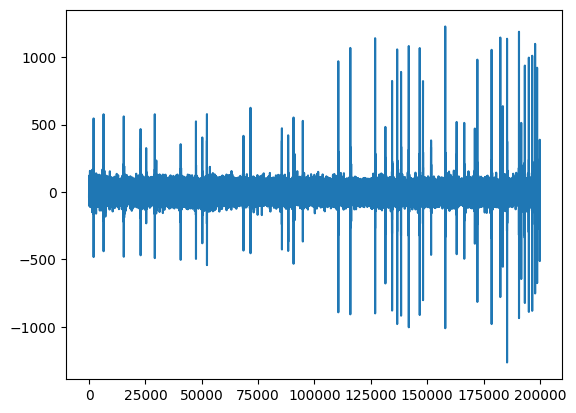

In [30]:
plt.plot(traces[1200000:1400000,8])

In [66]:
ephys.ClusteringParamSet & "paramset_idx > 300"

[2026-03-26 13:42:27,604][WARNING]: Reconnecting to MySQL server.


paramset_idx,clustering_method,paramset_desc,param_set_hash,params dictionary of all applicable parameters
301,kilosort3,"kilosort3 optimized for 100-um probe, sparse units, minimal channel spread",90ed1a20-ca95-1c59-2608-67248716dca4,=BLOB=
302,kilosort3,"kilosort3 for organoids,balanced sensitivity, medium whitening range",b51514ca-d2ba-a155-7d64-56b489bc2312,=BLOB=
303,kilosort3,"kilosort3 for organoids, more sensitive detection, higher nfilt_factor, broad whitening",ddd5dc04-82c9-f785-21bc-bf089f273e6f,=BLOB=
304,kilosort3,"kilosort 3 for organoids,conservative detection, higher preclust_threshold to reduce fragmentation",679a3ee6-9ef3-49b6-143e-c4a29737d91d,=BLOB=
305,kilosort3,"kilosort3 optimized for 100-um probe, chimera-sensitive",81d1bfdb-991e-8aa2-b626-135ccaf78f97,=BLOB=
400,kilosort4,Kilosort4 conservative profile for very low amplitudes,85dd2fa2-9e7c-7984-9d3c-dc24264c432a,=BLOB=
401,kilosort4,Kilosort4 standard profile for 100um probe spacing,75a2f1d3-b077-78bb-3a68-b8456644a9f1,=BLOB=
403,kilosort4,"KKilosort4 conservative profile , chimera-sensitive",059d3e65-d955-d459-1d11-d2235be42a8a,=BLOB=
405,kilosort4,Paramset 401 with installation mode set to pypi for SI sorting,ecae73ee-73ba-77bf-c7e4-8cf2f7189067,=BLOB=
475,spykingcircus2,Spyking circus2 with a detection threshold 4.75 (neg direction),cc552535-6116-c01c-01fe-bfaf34fe0e7d,=BLOB=


In [67]:
params = (ephys.ClusteringParamSet & "paramset_idx = 403").fetch1("params")

params

{'SI_PREPROCESSING_METHOD': 'organoid_preprocessing',
 'SI_SORTING_PARAMS': {'scale': 200,
  'skip_kilosort_preprocessing': True,
  'do_CAR': False,
  'n_pcs': 3,
  'Th_universal': 5.5,
  'Th_learned': 4.8,
  'whitening_range': 12,
  'nearest_chans': 8,
  'max_channel_distance': 220.0,
  'nblocks': 8,
  'keep_good_only': False},
 'SI_POSTPROCESSING_PARAMS': {'extensions': {'random_spikes': {},
   'waveforms': {},
   'templates': {},
   'noise_levels': {},
   'correlograms': {},
   'isi_histograms': {},
   'principal_components': {'n_components': 5, 'mode': 'by_channel_local'},
   'spike_amplitudes': {},
   'spike_locations': {},
   'template_metrics': {'include_multi_channel_metrics': True},
   'template_similarity': {},
   'unit_locations': {},
   'quality_metrics': {}},
  'job_kwargs': {'n_jobs': 10, 'chunk_duration': '2s'},
  'export_to_phy': True,
  'export_report': True}}

In [25]:
ephys.ClusteringParamSet.insert_new_params(
    clustering_method="kilosort3",
    paramset_desc = "param 304 with installation mode = pypi",
    params = params,
    paramset_idx = 3045
)

In [23]:
(ephys.ClusteringParamSet & "paramset_idx = 3045").delete()

[2026-03-19 12:05:20,714][INFO]: Deleting 1 rows from `utah_organoids_ephys_sorter`.`_pre_processing`
[2026-03-19 12:05:21,099][INFO]: Deleting 1 rows from `utah_organoids_ephys`.`clustering_task`
[2026-03-19 12:05:21,470][INFO]: Deleting 1 rows from `utah_organoids_ephys`.`#clustering_param_set`
[2026-03-19 12:05:27,494][INFO]: Deletes committed.


1

In [20]:
file_key = (ephys.EphysRawFile & f"file_time = '{sua_key['start_time']}'").fetch1("KEY")
exp_key = (culture.Experiment & f"organoid_id = '{sua_key['organoid_id']}'" & f"experiment_start_time = '{sua_key['experiment_start_time']}'").fetch1("KEY")

key = {**file_key, **exp_key}

In [21]:
from element_interface.utils import find_full_path
from spikeinterface.extractors.extractor_classes import (
      recording_extractor_full_dict,
)      

In [22]:
file, acq_software = (ephys.EphysRawFile & key).fetch1("file_path", "acq_software")
si_extractor = recording_extractor_full_dict[acq_software.replace(" ", "").lower()]

# Read data. Concatenate if multiple files are found.
file_path = find_full_path(ephys.get_ephys_root_data_dir(), file)

# Get stream name for this file
streams = si_extractor.get_streams(file_path)[0]
amplifier_streams = [s for s in streams if "amplifier" in s]
if not amplifier_streams:
    raise ValueError(f"No amplifier stream found in file: {file_path}")
stream_name = amplifier_streams[0]

# Get recording object
si_recording = si_extractor(file_path, stream_name=stream_name)
fs = si_recording.get_sampling_frequency()

# Get LFP indices (row index of the LFP matrix to be used)
port_id = set((ephys.EphysSessionProbe & key).fetch("port_id"))
# Figure out `Port ID` from the existing EphysSession
if not (ephys.EphysSessionProbe & key):
    raise ValueError(
        f"No EphysSessionProbe found for the {key} - cannot determine the port ID"
    )
# Check if there are multiple port IDs for the same experiment, if so, it needs to be fixed in the EphysSessionProbe table
if len(port_id) > 1:
    raise ValueError(
        f"Multiple Port IDs found for the {key} - cannot determine the port ID"
    )
port_id = port_id.pop()

# Get LFP channels
channel_ids = si_recording.get_channel_ids()

port_indices = np.array(
    [
        ind
        for ind, ch in enumerate(channel_ids)
        if ch.startswith(port_id)
    ]
)
channel_ids = channel_ids[port_indices]

# Get Traces
raw_traces = si_recording.get_traces(channel_ids=channel_ids, return_in_uV=True)

In [24]:
import spikeinterface as si

signed_recording = si.preprocessing.unsigned_to_signed(si_recording)
car_recording = si.preprocessing.common_reference(
    recording=signed_recording, operator="median")

signed_traces = signed_recording.get_traces(channel_ids=channel_ids, return_in_uV=True)
car_traces = car_recording.get_traces(channel_ids=channel_ids, return_in_uV=True)

from element_array_ephys.spike_sorting import si_preprocessing
si_preproc_func = getattr(si_preprocessing, "kilosort_preprocessing")
pipeline_recording = si_preproc_func(si_recording)
pipeline_traces = pipeline_recording.get_traces(channel_ids=channel_ids, return_in_uV=True)

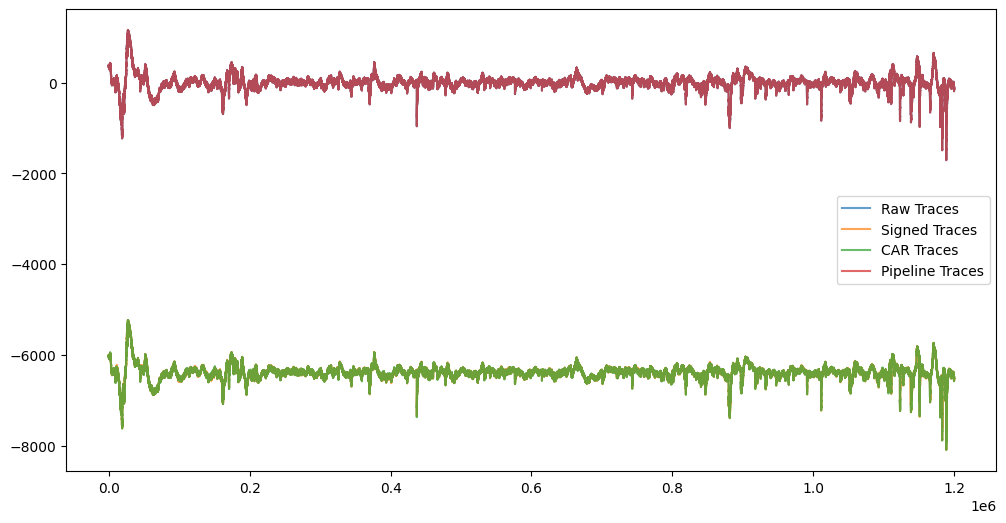

In [25]:
channel_idx = 8

# Plot raw and signed traces for the selected channel and time range
plt.figure(figsize=(12, 6))
plt.plot(raw_traces[:, channel_idx], label="Raw Traces", alpha=0.7)
plt.plot(signed_traces[:, channel_idx], label="Signed Traces", alpha=0.7)
plt.plot(car_traces[:, channel_idx], label="CAR Traces", alpha=0.7)
plt.plot(pipeline_traces[:, channel_idx], label="Pipeline Traces", alpha=0.7)
plt.legend()

In [113]:
start_idx = 120000
end_idx = 240000
start_idx = int(60 * fs * 1)
end_idx = int(60 * fs * 2)
raw_traces[start_idx:end_idx, channel_idx]

array([], dtype=uint16)

In [114]:
int(60 * fs * 1)

1200000